<a href="https://colab.research.google.com/github/soumensen411/Deep-Learning-Model/blob/main/CNN/CNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import MaxPooling2D,Dropout

In [136]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Deep Learning/CNN Project/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Deep Learning/CNN Project/test.csv')

In [137]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [138]:
df.shape

(42000, 785)

In [139]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [141]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [142]:
X_train = df.drop('label',axis = 1).values
y_train = df['label'].values

X_test = df_test.values  # X_test consists of all features from df_test
# y_test is not available for the test set; it needs to be predicted.

In [143]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [144]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [145]:
y_train_cat = to_categorical(y_train,10)
# y_test_cat = to_categorical(y_test,10) # y_test is not available for the test set.

In [146]:
model_perceptron = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [147]:
model_perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [148]:
history_perceptron = model_perceptron.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_split=0.1,verbose=1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7864 - loss: 0.9119 - val_accuracy: 0.8645 - val_loss: 0.5714
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8699 - loss: 0.5134 - val_accuracy: 0.8802 - val_loss: 0.4628
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8840 - loss: 0.4428 - val_accuracy: 0.8876 - val_loss: 0.4194
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8903 - loss: 0.4079 - val_accuracy: 0.8924 - val_loss: 0.3947
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8948 - loss: 0.3861 - val_accuracy: 0.8976 - val_loss: 0.3773
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8983 - loss: 0.3706 - val_accuracy: 0.9000 - val_loss: 0.3644
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9012 - loss: 0.3591 - val_accuracy: 0.9029 - val_loss: 0.3550
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9034 - loss: 0.3500 - 

In [149]:
predictions = model_perceptron.predict(X_test_img)[1]


875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [150]:
predictions

array([9.8981845e-01, 1.6153354e-08, 1.0662624e-04, 2.4223877e-05,
       8.4703650e-10, 9.8770242e-03, 2.3943076e-05, 8.3245730e-05,
       6.4651736e-05, 1.7312179e-06], dtype=float32)

In [151]:
model_ann = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(10,activation='softmax'),
])

In [152]:
model_ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [153]:
history_ann = model_ann.fit(X_train_img,y_train_cat,epochs=10,batch_size=32,validation_split=0.1,verbose=1)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9082 - loss: 0.3111 - val_accuracy: 0.9421 - val_loss: 0.1917
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9639 - loss: 0.1176 - val_accuracy: 0.9629 - val_loss: 0.1283
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9747 - loss: 0.0820 - val_accuracy: 0.9705 - val_loss: 0.0966
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9804 - loss: 0.0620 - val_accuracy: 0.9655 - val_loss: 0.1113
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9838 - loss: 0.0504 - val_accuracy: 0.9714 - val_loss: 0.1004
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9867 - loss: 0.0415 - val_accuracy: 0.9626 - val_loss: 0.1456
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9891 - loss: 0.0330 - val_accuracy: 0.9729 - val_loss: 0.1027
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9901 - loss: 0.0298 - 

In [154]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [155]:
model_cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [156]:
model_cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [157]:
history_cnn = model_cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_split=0.1,verbose=1)

Epoch 1/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9238 - loss: 0.2466 - val_accuracy: 0.9826 - val_loss: 0.0577
Epoch 2/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.9740 - loss: 0.0866 - val_accuracy: 0.9867 - val_loss: 0.0453
Epoch 3/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9816 - loss: 0.0617 - val_accuracy: 0.9860 - val_loss: 0.0422
Epoch 4/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.9847 - loss: 0.0507 - val_accuracy: 0.9886 - val_loss: 0.0374
Epoch 5/5
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9867 - loss: 0.0434 - val_accuracy: 0.9862 - val_loss: 0.0395


In [158]:
# acc_cnn = model_cnn.evaluate(X_test_cnn)[1]

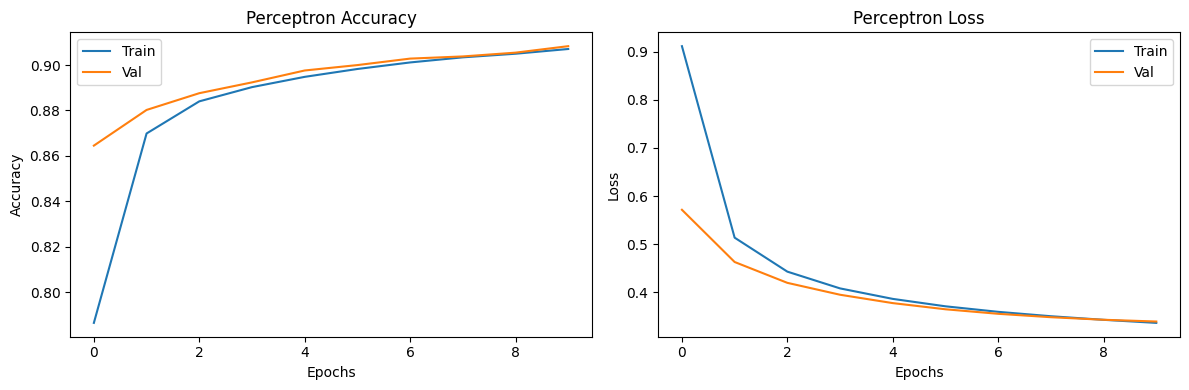

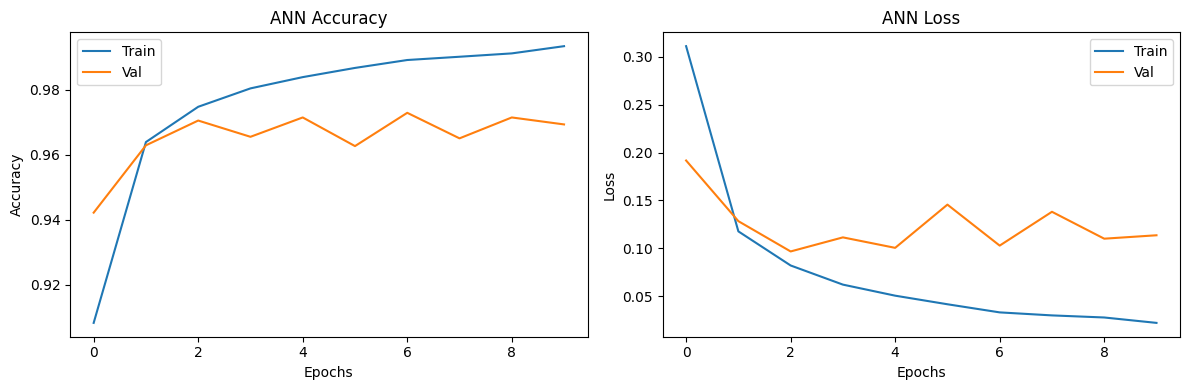

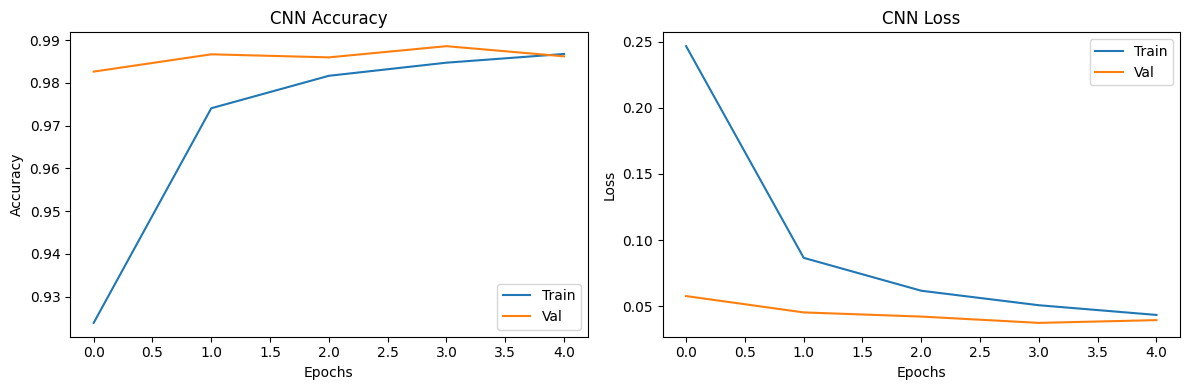

In [159]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f"{title} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(history_perceptron, "Perceptron")
plot_training(history_ann, "ANN")
plot_training(history_cnn, "CNN")

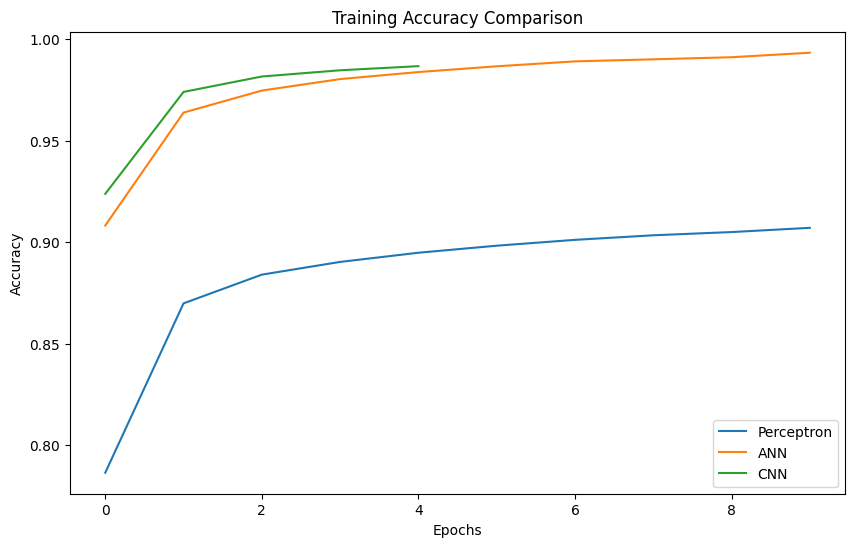

In [160]:
plt.figure(figsize=(10,6))
plt.plot(history_perceptron.history['accuracy'], label="Perceptron")
plt.plot(history_ann.history['accuracy'], label="ANN")
plt.plot(history_cnn.history['accuracy'], label="CNN")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

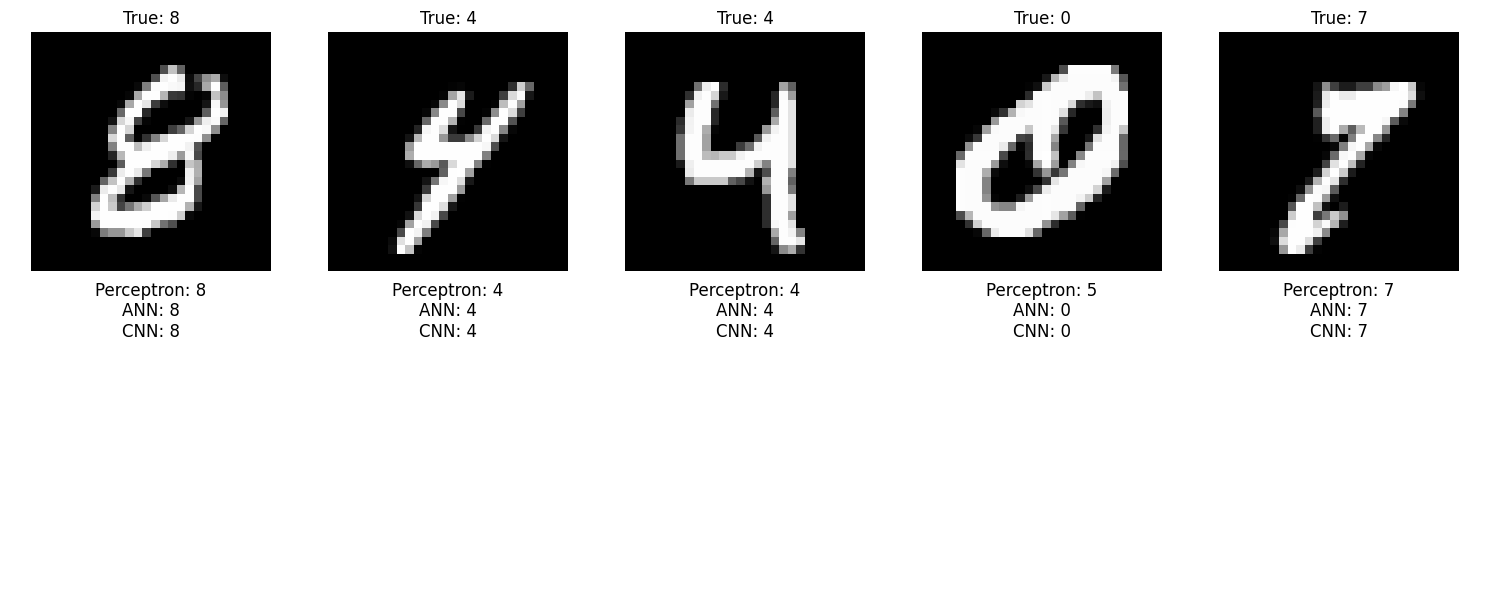

In [164]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        preds = []
        for model, name in zip(models, model_names):
            if name == "CNN":
                p = np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1), verbose=0))
            else:
                p = np.argmax(model.predict(X[idx].reshape(1, 28, 28), verbose=0))
            preds.append(p)

        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{name}: {p}" for name, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

show_side_by_side(
    models=[model_perceptron, model_ann, model_cnn],
    model_names=["Perceptron", "ANN", "CNN"],
    X=X_train_img,
    X_cnn=X_train_cnn,
    y_true=y_train,
    n=5
)